# 🔧 Day 25: GPU FinOps & Cost Optimization - Hands-on Lab

This notebook connects to a local Docker Compose cluster (via ngrok/cloudflared tunnel) to demonstrate:
1. **GPU Cluster Monitoring** - Real-time GPU metrics
2. **Cost Tracking (OpenCost-like)** - Per-node cost allocation & waste analysis
3. **Spot Instance Management** - Bidding, preemption, savings
4. **Autoscaling (KEDA-like)** - Policy-based GPU scaling
5. **Budget Management & Forecasting** - Alerts, burn rate

## Prerequisites
- Docker Compose running locally with the GPU FinOps Lab services
- Tunnel exposed via ngrok or cloudflared (free tier)

In [2]:
# Cell 1: Setup
!pip install -q requests pandas matplotlib plotly

import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
import json
from IPython.display import display, HTML, clear_output

In [3]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Phạm Minh Khôi"  
STUDENT_ID = "2A202600262"

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [4]:
# Cell 2: Configure Gateway URL
# Replace with your ngrok/cloudflared URL after running the tunnel
GATEWAY_URL = "https://theorem-cir-joined-dial.trycloudflare.com"

# Test connection
try:
    r = requests.get(f"{GATEWAY_URL}/", timeout=10)
    print("✅ Connected to GPU FinOps Lab Gateway")
    print(json.dumps(r.json(), indent=2))
except Exception as e:
    print(f"❌ Connection failed: {e}")
    print("Make sure Docker Compose is running and tunnel is active")

✅ Connected to GPU FinOps Lab Gateway
{
  "service": "GPU FinOps Lab Gateway",
  "endpoints": {
    "cluster": "/cluster/*",
    "billing": "/billing/*",
    "spot": "/spot/*",
    "autoscaler": "/autoscaler/*",
    "cost": "/cost/*"
  }
}


In [7]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Phạm Minh Khôi"  
STUDENT_ID = "2A202600262"

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


---
## Part 1: GPU Cluster Monitoring
Observe the mock GPU cluster state — nodes, utilization, memory, power draw.

In [5]:
# Cell 3: View Cluster Nodes
nodes = requests.get(f"{GATEWAY_URL}/cluster/nodes").json()

print(f"📊 Cluster has {len(nodes)} nodes")
print("=" * 60)

for node_id, gpus in nodes.items():
    print(f"\n🖥️  {node_id}:")
    for gpu in gpus:
        status_icon = "🟢" if gpu['status'] == 'idle' else "🔴"
        print(f"   GPU {gpu['gpu_id']} [{gpu['gpu_type']}] {status_icon} "
              f"Util: {gpu['utilization']:.1f}% | "
              f"Mem: {gpu['memory_used_gb']:.1f}/{gpu['memory_total_gb']}GB | "
              f"Power: {gpu['power_draw_watts']:.0f}W | "
              f"Temp: {gpu['temperature_c']:.0f}°C")

📊 Cluster has 4 nodes

🖥️  node-00:
   GPU 0 [T4] 🟢 Util: 4.7% | Mem: 1.4/16.0GB | Power: 21W | Temp: 39°C
   GPU 1 [T4] 🟢 Util: 7.1% | Mem: 0.7/16.0GB | Power: 35W | Temp: 44°C

🖥️  node-01:
   GPU 0 [A100] 🟢 Util: 4.0% | Mem: 1.1/80.0GB | Power: 48W | Temp: 44°C
   GPU 1 [A100] 🟢 Util: 12.3% | Mem: 1.7/80.0GB | Power: 27W | Temp: 42°C

🖥️  node-02:
   GPU 0 [V100] 🟢 Util: 10.3% | Mem: 0.9/32.0GB | Power: 31W | Temp: 32°C
   GPU 1 [V100] 🟢 Util: 2.9% | Mem: 1.2/32.0GB | Power: 23W | Temp: 43°C

🖥️  node-03:
   GPU 0 [T4] 🟢 Util: 9.5% | Mem: 1.8/16.0GB | Power: 31W | Temp: 32°C
   GPU 1 [T4] 🟢 Util: 1.4% | Mem: 1.8/16.0GB | Power: 23W | Temp: 42°C


In [9]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Phạm Minh Khôi"  
STUDENT_ID = "2A202600262"

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [8]:
# Cell 4: Cluster Metrics Summary
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()

print("📈 Cluster Metrics")
print("=" * 40)
print(f"Total GPUs:          {metrics['total_gpus']}")
print(f"Busy GPUs:           {metrics['busy_gpus']}")
print(f"Idle GPUs:           {metrics['idle_gpus']}")
print(f"Avg Utilization:     {metrics['avg_utilization']:.1f}%")
print(f"Memory Used:         {metrics['total_memory_used_gb']:.1f} GB")
print(f"Memory Capacity:     {metrics['total_memory_capacity_gb']:.1f} GB")
print(f"Total Power Draw:    {metrics['total_power_draw_watts']:.0f} W")
print(f"Node Count:          {metrics['node_count']}")

📈 Cluster Metrics
Total GPUs:          8
Busy GPUs:           0
Idle GPUs:           8
Avg Utilization:     6.5%
Memory Used:         10.6 GB
Memory Capacity:     288.0 GB
Total Power Draw:    239 W
Node Count:          4


In [11]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Phạm Minh Khôi"  
STUDENT_ID = "2A202600262"

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

display_student_header()


---
## Part 2: Workload Submission & Cost Tracking
Submit GPU workloads and track their costs in real-time.

In [10]:
# Cell 5: Submit multiple workloads
workloads = [
    {"workload_id": "train-resnet-001", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 300},
    {"workload_id": "train-bert-002", "gpu_type_preferred": "A100", "gpu_count": 1, "duration_seconds": 600},
    {"workload_id": "inference-api-003", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 120},
    {"workload_id": "train-llm-004", "gpu_type_preferred": "A100", "gpu_count": 2, "duration_seconds": 900},
]

print("🚀 Submitting workloads...")
for wl in workloads:
    r = requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json=wl)
    result = r.json()
    print(f"   {wl['workload_id']}: {result['status']} → {result.get('assigned', 'queued')}")

# Check cluster state after submission
print("\n📊 Updated metrics:")
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   Busy GPUs: {metrics['busy_gpus']}/{metrics['total_gpus']} | Utilization: {metrics['avg_utilization']:.1f}%")

🚀 Submitting workloads...
   train-resnet-001: running → [{'node_id': 'node-00', 'gpu_id': 0}]
   train-bert-002: running → [{'node_id': 'node-01', 'gpu_id': 0}]
   inference-api-003: running → [{'node_id': 'node-00', 'gpu_id': 1}]
   train-llm-004: running → [{'node_id': 'node-01', 'gpu_id': 1}, {'node_id': 'node-02', 'gpu_id': 0}]

📊 Updated metrics:
   Busy GPUs: 5/8 | Utilization: 47.6%


In [12]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Phạm Minh Khôi"  
STUDENT_ID = "2A202600262"

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

display_student_header()


In [13]:
# Cell 6: Record billing for workloads
billing_events = [
    {"workload_id": "train-resnet-001", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 300, "is_spot": False},
    {"workload_id": "train-bert-002", "gpu_type": "A100", "gpu_count": 1, "duration_seconds": 600, "is_spot": False},
    {"workload_id": "inference-api-003", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 120, "is_spot": True},
    {"workload_id": "train-llm-004", "gpu_type": "A100", "gpu_count": 2, "duration_seconds": 900, "is_spot": True},
]

print("💰 Recording billing events...")
for event in billing_events:
    r = requests.post(f"{GATEWAY_URL}/billing/record", json=event)
    result = r.json()
    spot_label = "[SPOT]" if event['is_spot'] else "[ON-DEMAND]"
    print(f"   {event['workload_id']} {spot_label}: ${result['total_cost_usd']:.4f} "
          f"(saved ${result['savings_usd']:.4f})")

# Get billing summary
print("\n📋 Billing Summary:")
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total Cost:     ${summary['total_cost_usd']:.4f}")
print(f"   Total Savings:  ${summary['total_savings_usd']:.4f}")
print(f"   Budget Used:    {summary['budget_utilization_pct']:.1f}%")
print(f"   Alert Status:   {summary['alert']}")

💰 Recording billing events...
   train-resnet-001 [ON-DEMAND]: $0.0292 (saved $0.0000)
   train-bert-002 [ON-DEMAND]: $0.6117 (saved $0.0000)
   inference-api-003 [SPOT]: $0.0035 (saved $0.0082)
   train-llm-004 [SPOT]: $0.5505 (saved $1.2845)

📋 Billing Summary:
   Total Cost:     $1.1949
   Total Savings:  $1.2927
   Budget Used:    1.2%
   Alert Status:   OK


In [14]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Phạm Minh Khôi"  
STUDENT_ID = "2A202600262"

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

display_student_header()


---
## Part 3: Spot Instance Management
Demonstrate spot bidding, preemption handling, and cost savings.

In [15]:
# Cell 7: Check spot pricing
spot_pricing = requests.get(f"{GATEWAY_URL}/spot/pricing").json()

print("💹 Current Spot Pricing")
print("=" * 60)
print(f"{'GPU Type':<10} {'On-Demand':<12} {'Spot Price':<12} {'Discount':<10} {'Availability'}")
print("-" * 60)
for gpu, info in spot_pricing.items():
    print(f"{gpu:<10} ${info['on_demand_price']:<10.2f} ${info['current_spot_price']:<10.4f} "
          f"{info['discount_pct']:<8.1f}% {info['availability']}")

💹 Current Spot Pricing
GPU Type   On-Demand    Spot Price   Discount   Availability
------------------------------------------------------------
T4         $0.35       $0.2413     31.1    % medium
A100       $3.67       $2.8457     22.5    % high
V100       $2.48       $1.8372     25.9    % medium


In [16]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Phạm Minh Khôi"  
STUDENT_ID = "2A202600262"

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

display_student_header()


In [17]:
# Cell 8: Request spot instances
spot_requests = [
    {"instance_id": "spot-t4-001", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": "batch-job-1"},
    {"instance_id": "spot-t4-002", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.12, "workload_id": "batch-job-2"},
    {"instance_id": "spot-a100-001", "gpu_type": "A100", "gpu_count": 1, "max_price_per_hour": 1.50, "workload_id": "training-3"},
]

print("🎯 Requesting Spot Instances...")
for req in spot_requests:
    r = requests.post(f"{GATEWAY_URL}/spot/request", json=req)
    result = r.json()
    status_icon = "✅" if result['status'] == 'granted' else "❌"
    print(f"   {status_icon} {req['instance_id']} ({req['gpu_type']}): {result['status']}")
    if result['status'] == 'rejected':
        print(f"      Reason: {result.get('reason', 'N/A')}")

🎯 Requesting Spot Instances...
   ✅ spot-t4-001 (T4): granted
   ✅ spot-t4-002 (T4): granted
   ✅ spot-a100-001 (A100): granted


In [18]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Phạm Minh Khôi"  
STUDENT_ID = "2A202600262"

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

display_student_header()


In [19]:
# Cell 9: Simulate spot preemption
print("⚡ Simulating spot preemption event...")
preemption = requests.post(f"{GATEWAY_URL}/spot/simulate-preemption").json()

print(f"\n   Preempted instances: {preemption['preempted_count']}")
print(f"   Still active: {preemption['total_active']}")

if preemption['preempted_instances']:
    print("\n   ⚠️  Preempted:")
    for p in preemption['preempted_instances']:
        print(f"      - {p['instance_id']} (ran for {p['runtime_seconds']:.0f}s, "
              f"{p['notice_seconds']}s warning)")

# Savings report
print("\n💰 Spot Savings Report:")
savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot cost:        ${savings['total_spot_cost']:.4f}")
print(f"   On-demand equiv:  ${savings['on_demand_equivalent']:.4f}")
print(f"   Total saved:      ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

⚡ Simulating spot preemption event...

   Preempted instances: 1
   Still active: 2

   ⚠️  Preempted:
      - spot-t4-002 (ran for 9s, 120s warning)

💰 Spot Savings Report:
   Spot cost:        $0.0030
   On-demand equiv:  $0.0101
   Total saved:      $0.0071 (70.0%)


In [20]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Phạm Minh Khôi"  
STUDENT_ID = "2A202600262"

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

display_student_header()


---
## Part 4: Autoscaling (KEDA-like)
Configure and trigger GPU autoscaling based on utilization thresholds.

In [21]:
# Cell 10: View and update autoscaling policy
policy = requests.get(f"{GATEWAY_URL}/autoscaler/policy").json()
print("📜 Current Autoscaling Policy:")
for k, v in policy.items():
    print(f"   {k}: {v}")

# Update policy - more aggressive scaling
new_policy = {
    "scale_up_threshold": 70,
    "scale_down_threshold": 25,
    "cooldown_seconds": 30,
    "max_nodes": 10,
    "min_nodes": 2,
    "preferred_gpu_type": "T4",
    "cost_aware": True
}

print("\n🔄 Updating policy...")
updated = requests.post(f"{GATEWAY_URL}/autoscaler/policy", json=new_policy).json()
print("   ✅ Policy updated")

📜 Current Autoscaling Policy:
   scale_up_threshold: 80.0
   scale_down_threshold: 20.0
   cooldown_seconds: 60
   max_nodes: 8
   min_nodes: 1
   preferred_gpu_type: T4
   cost_aware: True

🔄 Updating policy...
   ✅ Policy updated


In [23]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Phạm Minh Khôi"  
STUDENT_ID = "2A202600262"

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

display_student_header()


In [22]:
# Cell 11: Trigger autoscaler evaluation
print("🔄 Evaluating autoscaling decision...")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()

action_icons = {"scale_up": "⬆️", "scale_down": "⬇️", "no_action": "➡️"}
print(f"\n   {action_icons.get(decision['action'], '❓')} Action: {decision['action'].upper()}")
print(f"   Reason: {decision['reason']}")
print(f"   Current utilization: {decision['current_utilization']:.1f}%")
print(f"   Nodes: {decision['node_count']} → {decision['target_node_count']}")

# Run multiple evaluations to show scaling behavior
print("\n📊 Running 5 evaluation cycles...")
for i in range(5):
    time.sleep(2)
    d = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
    print(f"   Cycle {i+1}: {d['action']:<12} | Util: {d['current_utilization']:.1f}% | Nodes: {d['node_count']}→{d['target_node_count']}")

🔄 Evaluating autoscaling decision...

   ➡️ Action: NO_ACTION
   Reason: Utilization 47.6% within thresholds [25.0-70.0%]
   Current utilization: 47.6%
   Nodes: 4 → 4

📊 Running 5 evaluation cycles...
   Cycle 1: no_action    | Util: 47.6% | Nodes: 4→4
   Cycle 2: no_action    | Util: 47.6% | Nodes: 4→4
   Cycle 3: no_action    | Util: 47.6% | Nodes: 4→4
   Cycle 4: no_action    | Util: 47.6% | Nodes: 4→4
   Cycle 5: no_action    | Util: 47.6% | Nodes: 4→4


In [26]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Phạm Minh Khôi"  
STUDENT_ID = "2A202600262"

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

display_student_header()


---
## Part 5: Cost Analysis & Optimization (OpenCost-like)
Analyze cost allocation, identify waste, and get recommendations.

In [24]:
# Cell 12: Take cost snapshots
print("📸 Taking cost snapshots...")
snapshots = []
for i in range(5):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    snapshots.append(snap)
    print(f"   Snapshot {i+1}: Total=${snap['total_cost_usd']:.6f} | "
          f"Idle=${snap['total_idle_cost_usd']:.6f} | "
          f"Waste={snap['waste_pct']:.1f}%")
    time.sleep(1)

📸 Taking cost snapshots...
   Snapshot 1: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%
   Snapshot 2: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%
   Snapshot 3: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%
   Snapshot 4: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%
   Snapshot 5: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%


In [27]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Phạm Minh Khôi"  
STUDENT_ID = "2A202600262"

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

display_student_header()


In [25]:
# Cell 13: Waste Report
waste = requests.get(f"{GATEWAY_URL}/cost/waste-report").json()

print("🗑️  WASTE ANALYSIS REPORT")
print("=" * 50)
print(f"   Average Waste:          {waste.get('avg_waste_pct', 0):.1f}%")
print(f"   Total Idle Cost:        ${waste.get('total_idle_cost_usd', 0):.6f}")
print(f"   Total Cost:             ${waste.get('total_cost_usd', 0):.6f}")
print(f"   Potential Monthly Save:  ${waste.get('potential_monthly_savings', 0):.2f}")
print(f"   Severity:               {waste.get('severity', 'N/A')}")

🗑️  WASTE ANALYSIS REPORT
   Average Waste:          23.2%
   Total Idle Cost:        $0.044165
   Total Cost:             $0.190280
   Potential Monthly Save:  $2289.51
   Severity:               LOW


In [29]:

display_student_header()


In [28]:
# Cell 14: Get Optimization Recommendations
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()

print("💡 COST OPTIMIZATION RECOMMENDATIONS")
print("=" * 60)
for i, rec in enumerate(recs, 1):
    priority_icons = {"HIGH": "🔴", "MEDIUM": "🟡", "LOW": "🟢"}
    icon = priority_icons.get(rec['priority'], '⚪')
    print(f"\n{i}. {icon} [{rec['priority']}] {rec['type']}")
    print(f"   {rec['description']}")
    print(f"   Estimated savings: {rec['estimated_savings_pct']:.1f}%")

💡 COST OPTIMIZATION RECOMMENDATIONS

1. 🟡 [MEDIUM] USE_SPOT
   Switch fault-tolerant workloads to spot instances for 60-70% savings.
   Estimated savings: 65.0%

2. 🟢 [LOW] SCHEDULING
   Schedule non-urgent training jobs during off-peak hours for lower spot prices.
   Estimated savings: 20.0%


In [30]:

display_student_header()


In [31]:
# Cell 15: Full Dashboard View
dashboard = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()

print("📊 GPU FinOps DASHBOARD")
print("=" * 60)

cm = dashboard.get('cluster_metrics', {})
print(f"\n🖥️  CLUSTER: {cm.get('total_gpus', 0)} GPUs across {cm.get('node_count', 0)} nodes")
print(f"   Utilization: {cm.get('avg_utilization', 0):.1f}% | Busy: {cm.get('busy_gpus', 0)} | Idle: {cm.get('idle_gpus', 0)}")

bs = dashboard.get('billing_summary', {})
print(f"\n💰 BILLING: ${bs.get('total_cost_usd', 0):.4f} / ${bs.get('budget_usd', 0):.2f} budget")
print(f"   Alert: {bs.get('alert', 'N/A')} | Savings: ${bs.get('total_savings_usd', 0):.4f}")

ss = dashboard.get('spot_savings', {})
print(f"\n🎯 SPOT: Saved ${ss.get('total_savings', 0):.4f} ({ss.get('savings_pct', 0):.1f}%)")

wa = dashboard.get('waste_analysis', {})
if wa:
    print(f"\n🗑️  WASTE: {wa.get('avg_waste_pct', 0):.1f}% | Severity: {wa.get('severity', 'N/A')}")

📊 GPU FinOps DASHBOARD

🖥️  CLUSTER: 8 GPUs across 4 nodes
   Utilization: 47.6% | Busy: 5 | Idle: 3

💰 BILLING: $1.1949 / $100.00 budget
   Alert: OK | Savings: $1.2927

🎯 SPOT: Saved $0.2118 (70.0%)

🗑️  WASTE: 23.2% | Severity: LOW


---
## Part 6: Visualization
Create charts for cost breakdown and utilization trends.

In [32]:

display_student_header()


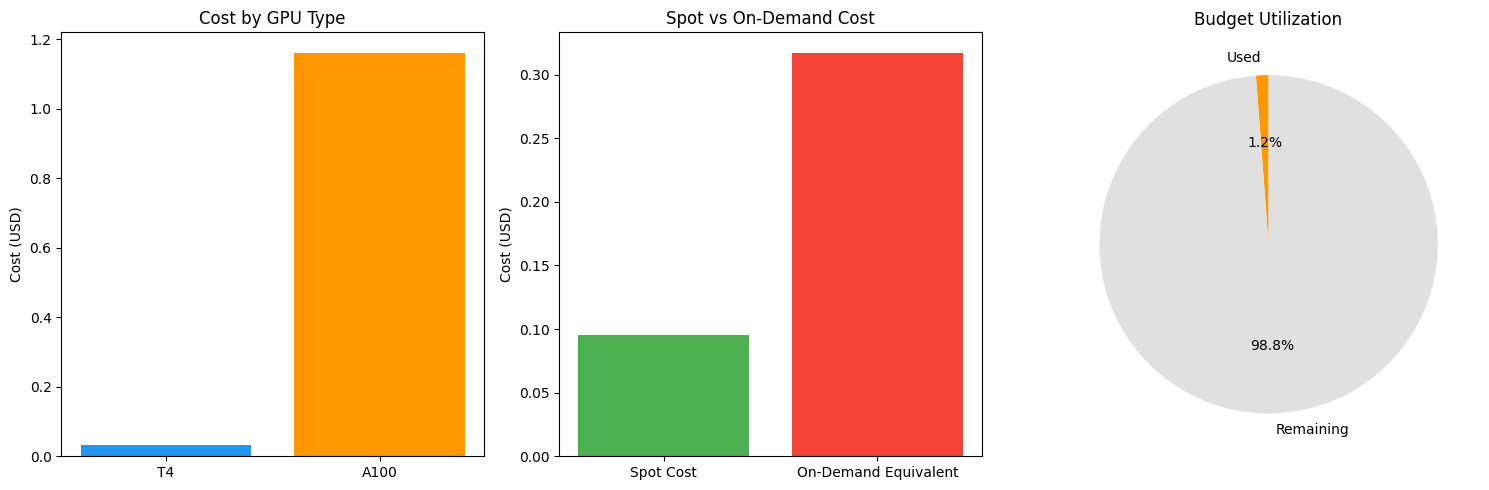

📊 Chart saved as finops_cost_breakdown.png


In [33]:
# Cell 16: Cost Breakdown Visualization
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1: Cost by GPU type
cost_by_type = summary.get('cost_by_gpu_type', {})
if cost_by_type:
    types = list(cost_by_type.keys())
    costs = [cost_by_type[t]['cost'] for t in types]
    axes[0].bar(types, costs, color=['#2196F3', '#FF9800', '#4CAF50'])
    axes[0].set_title('Cost by GPU Type')
    axes[0].set_ylabel('Cost (USD)')

# Chart 2: Spot vs On-Demand
spot_data = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
labels = ['Spot Cost', 'On-Demand Equivalent']
values = [spot_data.get('total_spot_cost', 0), spot_data.get('on_demand_equivalent', 0)]
axes[1].bar(labels, values, color=['#4CAF50', '#F44336'])
axes[1].set_title('Spot vs On-Demand Cost')
axes[1].set_ylabel('Cost (USD)')

# Chart 3: Budget utilization
budget_used = summary.get('budget_utilization_pct', 0)
axes[2].pie([budget_used, 100-budget_used], labels=['Used', 'Remaining'],
            colors=['#FF9800', '#E0E0E0'], autopct='%1.1f%%', startangle=90)
axes[2].set_title('Budget Utilization')

plt.tight_layout()
plt.savefig('finops_cost_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Chart saved as finops_cost_breakdown.png")

In [34]:

display_student_header()


📈 Collecting time-series data (10 snapshots)...


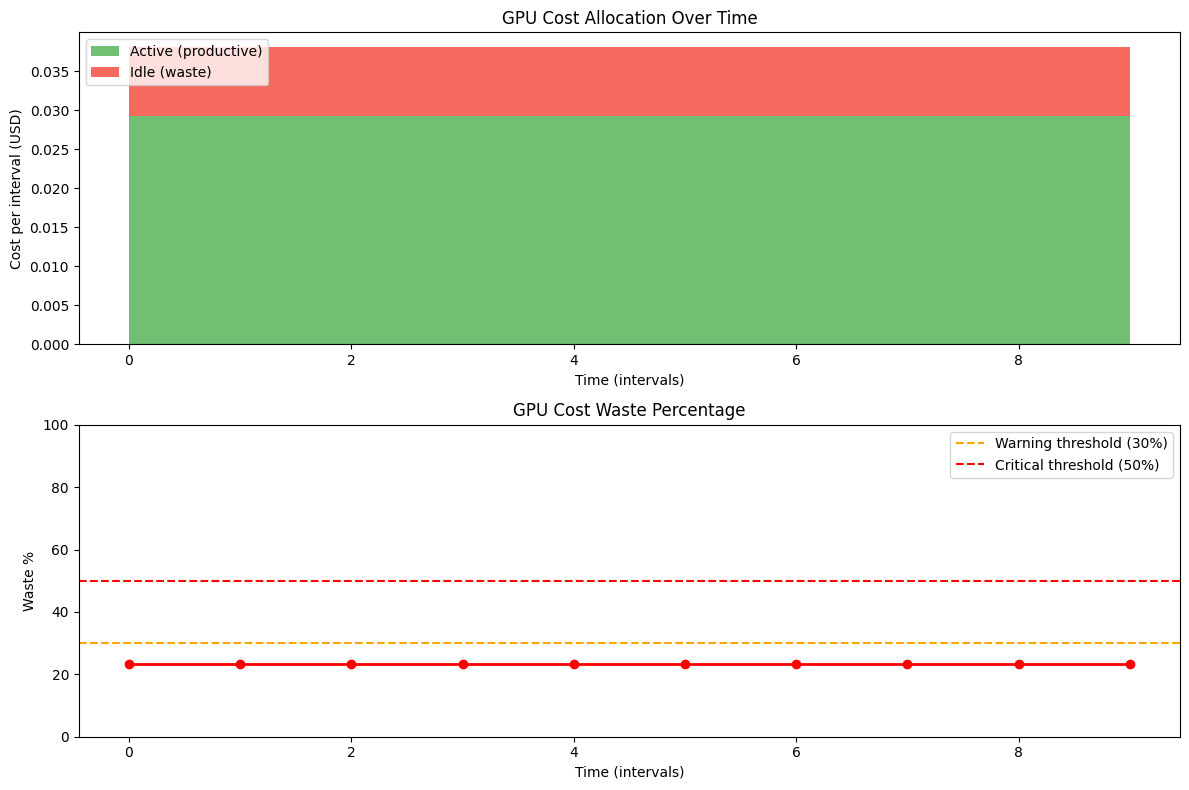

In [35]:
# Cell 17: Time-series cost tracking
print("📈 Collecting time-series data (10 snapshots)...")
ts_data = []
for i in range(10):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    ts_data.append({
        'time': i,
        'total_cost': snap['total_cost_usd'],
        'idle_cost': snap['total_idle_cost_usd'],
        'active_cost': snap['total_active_cost_usd'],
        'waste_pct': snap['waste_pct'],
    })
    time.sleep(1)

df = pd.DataFrame(ts_data)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Cost over time
ax1.stackplot(df['time'], df['active_cost'], df['idle_cost'],
              labels=['Active (productive)', 'Idle (waste)'],
              colors=['#4CAF50', '#F44336'], alpha=0.8)
ax1.set_xlabel('Time (intervals)')
ax1.set_ylabel('Cost per interval (USD)')
ax1.set_title('GPU Cost Allocation Over Time')
ax1.legend(loc='upper left')

# Waste percentage
ax2.plot(df['time'], df['waste_pct'], 'r-o', linewidth=2)
ax2.axhline(y=30, color='orange', linestyle='--', label='Warning threshold (30%)')
ax2.axhline(y=50, color='red', linestyle='--', label='Critical threshold (50%)')
ax2.set_xlabel('Time (intervals)')
ax2.set_ylabel('Waste %')
ax2.set_title('GPU Cost Waste Percentage')
ax2.legend()
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('finops_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 7: Complete FinOps Workflow
Run a full cycle: submit workloads → monitor → detect waste → autoscale → optimize cost.

In [37]:

display_student_header()


In [36]:
# Cell 18: Full FinOps Optimization Workflow
print("🔄 FULL FINOPS OPTIMIZATION WORKFLOW")
print("=" * 60)
# Step 1: Check initial state
print("\n1️⃣  Initial cluster state:")
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   GPUs: {m['total_gpus']} | Util: {m['avg_utilization']:.1f}% | Idle: {m['idle_gpus']}")
# Step 2: Submit heavy workloads to increase utilization
print("\n2️⃣  Submitting heavy workloads...")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 600
    })
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   After load: Util: {m['avg_utilization']:.1f}% | Busy: {m['busy_gpus']}/{m['total_gpus']}")
# Step 3: Autoscaler evaluates
print("\n3️⃣  Autoscaler evaluation:")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
print(f"   Decision: {decision['action']} - {decision['reason']}")
# Step 4: Cost snapshot
print("\n4️⃣  Cost analysis:")
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"   Total cost/interval: ${snap['total_cost_usd']:.6f}")
print(f"   Waste: {snap['waste_pct']:.1f}%")

# Step 5: Get recommendations
print("\n5️⃣  Recommendations:")
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()
for rec in recs:
    print(f"   [{rec['priority']}] {rec['type']}: savings ~{rec['estimated_savings_pct']}%")

# Step 6: Apply optimization - use spot for some workloads
print("\n6️⃣  Applying optimization: Switch to spot instances...")
for i in range(3):
    requests.post(f"{GATEWAY_URL}/spot/request", json={
        "instance_id": f"opt-spot-{i}", "gpu_type": "T4",
        "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": f"heavy-{i:03d}"
    })
savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot savings: ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

# Step 7: Complete workloads and record billing
print("\n7️⃣  Final billing:")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/heavy-{i:03d}/complete")
    requests.post(f"{GATEWAY_URL}/billing/record", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type": "T4",
        "gpu_count": 1, "duration_seconds": 600, "is_spot": i < 3
    })
final = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total spend: ${final['total_cost_usd']:.4f}")
print(f"   Total saved: ${final['total_savings_usd']:.4f}")
print(f"   Budget: {final['budget_utilization_pct']:.1f}% used")
print(f"\n✅ Workflow complete!")

🔄 FULL FINOPS OPTIMIZATION WORKFLOW

1️⃣  Initial cluster state:
   GPUs: 8 | Util: 47.6% | Idle: 3

2️⃣  Submitting heavy workloads...
   After load: Util: 74.9% | Busy: 8/8

3️⃣  Autoscaler evaluation:
   Decision: scale_up - Utilization 74.9% > threshold 70.0%

4️⃣  Cost analysis:
   Total cost/interval: $0.040000
   Waste: 4.9%

5️⃣  Recommendations:
   [MEDIUM] USE_SPOT: savings ~65.0%
   [LOW] SCHEDULING: savings ~20.0%

6️⃣  Applying optimization: Switch to spot instances...
   Spot savings: $0.4041 (70.0%)

7️⃣  Final billing:
   Total spend: $1.3640
   Total saved: $1.4151
   Budget: 1.4% used

✅ Workflow complete!


---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** to measure time & cost savings
4. Reports all costs back to the FinOps gateway

In [39]:
display_student_header()

In [38]:
# Cell 19: Install dependencies & detect real GPU
!pip install -q torch torchvision pynvml

import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
import subprocess
import threading

try:
    from pynvml import (nvmlInit, nvmlDeviceGetHandleByIndex,
                        nvmlDeviceGetUtilizationRates, nvmlDeviceGetMemoryInfo,
                        nvmlDeviceGetPowerUsage, nvmlDeviceGetTemperature)
    PYNVML_AVAILABLE = True
except ImportError:
    PYNVML_AVAILABLE = False
    print("pynvml not available, will use torch.cuda fallback for monitoring")

# Detect GPU
if not torch.cuda.is_available():
    raise RuntimeError("No GPU detected! Enable GPU in Kaggle/Colab settings.")

gpu_name = torch.cuda.get_device_name(0)
gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9

# Map real GPU to pricing
GPU_PRICING = {"T4": 0.35, "A100": 3.67, "V100": 2.48, "P100": 1.46, "L4": 0.81}
detected_type = "T4"  # default
for gtype in GPU_PRICING:
    if gtype.lower() in gpu_name.lower():
        detected_type = gtype
        break

print(f"Real GPU Detected")
print(f"   Name:    {gpu_name}")
print(f"   Memory:  {gpu_mem:.1f} GB")
print(f"   Type:    {detected_type}")
print(f"   Pricing: ${GPU_PRICING[detected_type]:.2f}/hr (on-demand)")
print(f"   CUDA:    {torch.version.cuda}")
print(f"   pynvml:  {'available' if PYNVML_AVAILABLE else 'NOT available'}")

Real GPU Detected
   Name:    Tesla T4
   Memory:  15.6 GB
   Type:    T4
   Pricing: $0.35/hr (on-demand)
   CUDA:    12.8
   pynvml:  available


In [40]:
display_student_header()

In [41]:
# Cell 20: GPU Metrics Collection (works on Kaggle/Colab)
# Strategy: pynvml first (reliable Python lib), torch.cuda fallback
def get_gpu_metrics():
    """Get GPU metrics inline. Called during training loop."""
    # Method 1: pynvml (most reliable on Kaggle - pure Python, no subprocess)
    if PYNVML_AVAILABLE:
        try:
            nvmlInit()
            handle = nvmlDeviceGetHandleByIndex(0)
            util = nvmlDeviceGetUtilizationRates(handle)
            mem_info = nvmlDeviceGetMemoryInfo(handle)
            try:
                power = nvmlDeviceGetPowerUsage(handle) / 1000.0  # mW -> W
            except Exception:
                power = 0.0
            try:
                temp = nvmlDeviceGetTemperature(handle, 0)  # NVML_TEMPERATURE_GPU = 0
            except Exception:
                temp = 0.0
            return {
                'timestamp': time.time(),
                'gpu_util_pct': float(util.gpu),
                'mem_util_pct': float(util.memory),
                'mem_used_mb': mem_info.used / 1e6,
                'mem_total_mb': mem_info.total / 1e6,
                'power_watts': float(power),
                'temp_c': float(temp),
            }
        except Exception as e:
            pass  # Fall through to torch.cuda
    # Method 2: torch.cuda (always works, limited metrics)
    mem_used = torch.cuda.memory_allocated() / 1e6
    mem_reserved = torch.cuda.memory_reserved() / 1e6
    mem_total = torch.cuda.get_device_properties(0).total_memory / 1e6
    util_approx = (mem_reserved / mem_total) * 100 if mem_total > 0 else 0
    return {
        'timestamp': time.time(),
        'gpu_util_pct': util_approx,
        'mem_util_pct': util_approx,
        'mem_used_mb': mem_used,
        'mem_total_mb': mem_total,
        'power_watts': 0.0,
        'temp_c': 0.0,
    }
# === DIAGNOSTIC TEST ===
print("=" * 50)
print("GPU METRICS DIAGNOSTIC")
print("=" * 50)
# Test pynvml
print(f"\n1. pynvml available: {PYNVML_AVAILABLE}")
if PYNVML_AVAILABLE:
    try:
        nvmlInit()
        handle = nvmlDeviceGetHandleByIndex(0)
        util = nvmlDeviceGetUtilizationRates(handle)
        mem = nvmlDeviceGetMemoryInfo(handle)
        print(f"   pynvml works! GPU util={util.gpu}%, mem={mem.used/1e6:.0f}/{mem.total/1e6:.0f} MB")
        try:
            pwr = nvmlDeviceGetPowerUsage(handle) / 1000.0
            print(f"   Power: {pwr:.1f}W")
        except Exception as e:
            print(f"   Power: not available ({e})")
        try:
            tmp = nvmlDeviceGetTemperature(handle, 0)
            print(f"   Temp: {tmp}C")
        except Exception as e:
            print(f"   Temp: not available ({e})")
    except Exception as e:
        print(f"   pynvml FAILED: {e}")
# Test full function
print(f"\n2. get_gpu_metrics() test:")
test_result = get_gpu_metrics()
for k, v in sorted(test_result.items()):
    if k != 'timestamp':
        print(f"   {k}: {v}")
print(f"\n   Method: {'pynvml' if test_result.get('temp_c', 0) > 0 or (PYNVML_AVAILABLE and test_result.get('gpu_util_pct', -1) >= 0) else 'torch.cuda'}")
print(f"\nReady for training.")

GPU METRICS DIAGNOSTIC

1. pynvml available: True
   pynvml works! GPU util=0%, mem=472/16106 MB
   Power: 10.3W
   Temp: 37C

2. get_gpu_metrics() test:
   gpu_util_pct: 0.0
   mem_total_mb: 16106.12736
   mem_used_mb: 472.055808
   mem_util_pct: 0.0
   power_watts: 10.304
   temp_c: 37.0

   Method: pynvml

Ready for training.


In [42]:
display_student_header()

In [43]:
# Cell 21: Prepare CIFAR-10 dataset and ResNet-18 model
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
]))
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=2)

print(f"Dataset ready: {len(trainset)} train / {len(testset)} test images")
print(f"Batches per epoch: {len(trainloader)}")


def create_model():
    """Create a fresh ResNet-18 for CIFAR-10."""
    model = torchvision.models.resnet18(weights=None, num_classes=10)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model.cuda()


def train_epoch_monitored(model, loader, optimizer, criterion, use_amp=False, sample_interval=10):
    """Train one epoch with inline GPU metrics collection every N batches."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    scaler = GradScaler() if use_amp else None
    metrics_samples = []
    start = time.time()

    for batch_idx, (inputs, targets) in enumerate(loader):
        inputs, targets = inputs.cuda(), targets.cuda()
        optimizer.zero_grad()

        if use_amp:
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total += inputs.size(0)

        # Collect GPU metrics every N batches (inline, no threading)
        if batch_idx % sample_interval == 0:
            torch.cuda.synchronize()
            sample = get_gpu_metrics()
            metrics_samples.append(sample)

    elapsed = time.time() - start
    return total_loss / total, correct / total * 100, elapsed, metrics_samples


print("Model & training functions ready (inline monitoring every 10 batches)")

100%|██████████| 170M/170M [00:02<00:00, 71.7MB/s] 


Dataset ready: 50000 train / 10000 test images
Batches per epoch: 391
Model & training functions ready (inline monitoring every 10 batches)


In [46]:

display_student_header()


In [44]:
# Cell 22: Train FP32 (baseline) with inline GPU monitoring
NUM_EPOCHS = 3
price_per_hour = GPU_PRICING[detected_type]

print("=" * 60)
print("EXPERIMENT 1: FP32 Training (Baseline)")
print("=" * 60)

model_fp32 = create_model()
optimizer_fp32 = optim.SGD(model_fp32.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
fp32_start = time.time()

fp32_results = []
fp32_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_fp32, trainloader, optimizer_fp32, criterion, use_amp=False)
    fp32_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    fp32_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

fp32_total_time = time.time() - fp32_start
fp32_peak_mem = torch.cuda.max_memory_allocated() / 1e9
fp32_cost = (fp32_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(fp32_all_metrics)}")

# Build monitor dataframe
fp32_monitor_df = pd.DataFrame(fp32_all_metrics)
if not fp32_monitor_df.empty and 'timestamp' in fp32_monitor_df.columns:
    fp32_monitor_df['elapsed'] = fp32_monitor_df['timestamp'] - fp32_monitor_df['timestamp'].iloc[0]

print(f"\n   FP32 Summary:")
print(f"   Total time:      {fp32_total_time:.1f}s")
print(f"   Peak memory:     {fp32_peak_mem:.2f} GB")
if not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns:
    print(f"   Avg GPU util:    {fp32_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {fp32_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {fp32_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {fp32_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(fp32_monitor_df.columns) if not fp32_monitor_df.empty else 'EMPTY'}")
    if fp32_all_metrics:
        print(f"   First sample keys: {list(fp32_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${fp32_cost:.6f}")

EXPERIMENT 1: FP32 Training (Baseline)
   Epoch 1/3 | Loss: 1.8459 | Acc: 32.9% | Time: 40.3s | Samples: 40
   Epoch 2/3 | Loss: 1.2925 | Acc: 53.0% | Time: 39.9s | Samples: 40
   Epoch 3/3 | Loss: 0.9835 | Acc: 65.1% | Time: 43.7s | Samples: 40

   Total samples collected: 120

   FP32 Summary:
   Total time:      123.9s
   Peak memory:     0.82 GB
   Avg GPU util:    95.5%
   Avg power:       67.1W
   Avg temperature: 62.6C
   Max GPU util:    99.0%
   Estimated cost:  $0.012044


In [48]:

display_student_header()


In [47]:
# Cell 23: Train Mixed Precision AMP (optimized) with inline GPU monitoring
print("=" * 60)
print("EXPERIMENT 2: Mixed Precision (AMP) Training")
print("=" * 60)

model_amp = create_model()
optimizer_amp = optim.SGD(model_amp.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
amp_start = time.time()

amp_results = []
amp_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_amp, trainloader, optimizer_amp, criterion, use_amp=True)
    amp_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    amp_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

amp_total_time = time.time() - amp_start
amp_peak_mem = torch.cuda.max_memory_allocated() / 1e9
amp_cost = (amp_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(amp_all_metrics)}")

# Build monitor dataframe
amp_monitor_df = pd.DataFrame(amp_all_metrics)
if not amp_monitor_df.empty and 'timestamp' in amp_monitor_df.columns:
    amp_monitor_df['elapsed'] = amp_monitor_df['timestamp'] - amp_monitor_df['timestamp'].iloc[0]

print(f"\n   AMP Summary:")
print(f"   Total time:      {amp_total_time:.1f}s")
print(f"   Peak memory:     {amp_peak_mem:.2f} GB")
if not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns:
    print(f"   Avg GPU util:    {amp_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {amp_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {amp_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {amp_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(amp_monitor_df.columns) if not amp_monitor_df.empty else 'EMPTY'}")
    if amp_all_metrics:
        print(f"   First sample keys: {list(amp_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${amp_cost:.6f}")

EXPERIMENT 2: Mixed Precision (AMP) Training


/tmp/ipykernel_114/927799492.py:34: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if use_amp else None
/tmp/ipykernel_114/927799492.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


   Epoch 1/3 | Loss: 2.1658 | Acc: 23.4% | Time: 21.2s | Samples: 40
   Epoch 2/3 | Loss: 1.6158 | Acc: 40.2% | Time: 20.8s | Samples: 40
   Epoch 3/3 | Loss: 1.3458 | Acc: 50.9% | Time: 19.9s | Samples: 40

   Total samples collected: 120

   AMP Summary:
   Total time:      61.9s
   Peak memory:     0.60 GB
   Avg GPU util:    91.5%
   Avg power:       65.0W
   Avg temperature: 78.0C
   Max GPU util:    96.0%
   Estimated cost:  $0.006016


FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)

Metric                    FP32            AMP             Improvement
----------------------------------------------------------------------
Total Time                123.9           61.9            2.00x faster
Peak Memory (GB)          0.82            0.60            0.22 GB saved
Cost (USD)                $0.012044       $0.006016       $0.006029 saved
Cost Saving %             ---             ---             50.1%
Avg GPU Util %            95.5            91.5           
Avg Power (W)             67.1            65.0           

--- Extrapolated Savings at Scale ---
   1 day training: FP32=$8.40 vs AMP=$4.20 -> SAVE $4.20
   1 week training: FP32=$58.80 vs AMP=$29.37 -> SAVE $29.43
   1 month training: FP32=$252.00 vs AMP=$125.87 -> SAVE $126.13


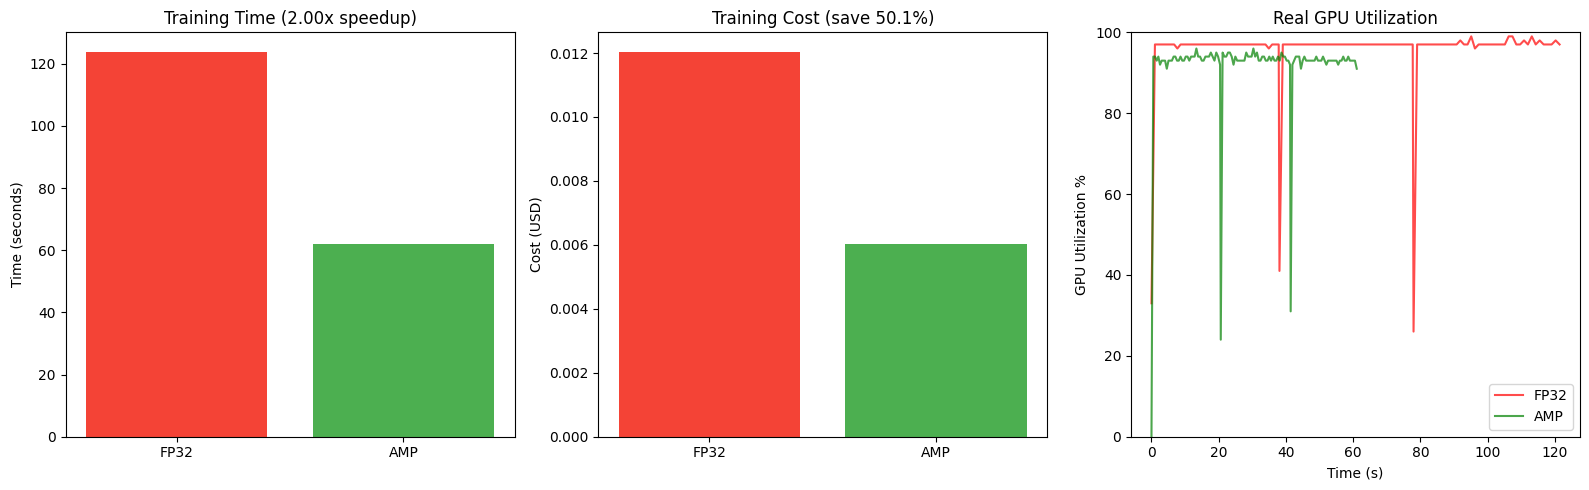

In [49]:
display_student_header()
# Cell 24: Compare FP32 vs AMP - FinOps Analysis
print("=" * 60)
print("FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)")
print("=" * 60)

speedup = fp32_total_time / amp_total_time
cost_saving = fp32_cost - amp_cost
cost_saving_pct = (cost_saving / fp32_cost) * 100 if fp32_cost > 0 else 0
mem_saving = fp32_peak_mem - amp_peak_mem

print(f"\n{'Metric':<25} {'FP32':<15} {'AMP':<15} {'Improvement'}")
print("-" * 70)
print(f"{'Total Time':<25} {fp32_total_time:<15.1f} {amp_total_time:<15.1f} {speedup:.2f}x faster")
print(f"{'Peak Memory (GB)':<25} {fp32_peak_mem:<15.2f} {amp_peak_mem:<15.2f} {mem_saving:.2f} GB saved")
print(f"{'Cost (USD)':<25} ${fp32_cost:<14.6f} ${amp_cost:<14.6f} ${cost_saving:.6f} saved")
print(f"{'Cost Saving %':<25} {'---':<15} {'---':<15} {cost_saving_pct:.1f}%")

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    print(f"{'Avg GPU Util %':<25} {fp32_monitor_df['gpu_util_pct'].mean():<15.1f} {amp_monitor_df['gpu_util_pct'].mean():<15.1f}")
    print(f"{'Avg Power (W)':<25} {fp32_monitor_df['power_watts'].mean():<15.1f} {amp_monitor_df['power_watts'].mean():<15.1f}")

# Extrapolate to larger scale
print(f"\n--- Extrapolated Savings at Scale ---")
for scale_name, hours in [("1 day training", 24), ("1 week training", 168), ("1 month training", 720)]:
    fp32_scaled = hours * price_per_hour
    amp_scaled = (hours / speedup) * price_per_hour
    saved = fp32_scaled - amp_scaled
    print(f"   {scale_name}: FP32=${fp32_scaled:.2f} vs AMP=${amp_scaled:.2f} -> SAVE ${saved:.2f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar: Time comparison
axes[0].bar(['FP32', 'AMP'], [fp32_total_time, amp_total_time], color=['#F44336', '#4CAF50'])
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title(f'Training Time ({speedup:.2f}x speedup)')

# Bar: Cost comparison
axes[1].bar(['FP32', 'AMP'], [fp32_cost, amp_cost], color=['#F44336', '#4CAF50'])
axes[1].set_ylabel('Cost (USD)')
axes[1].set_title(f'Training Cost (save {cost_saving_pct:.1f}%)')

# Line: GPU utilization over time (both experiments) or epoch time
if has_monitor_data:
    if not fp32_monitor_df.empty:
        axes[2].plot(fp32_monitor_df['elapsed'], fp32_monitor_df['gpu_util_pct'], 'r-', alpha=0.7, label='FP32')
    if not amp_monitor_df.empty:
        axes[2].plot(amp_monitor_df['elapsed'], amp_monitor_df['gpu_util_pct'], 'g-', alpha=0.7, label='AMP')
    axes[2].set_xlabel('Time (s)')
    axes[2].set_ylabel('GPU Utilization %')
    axes[2].set_title('Real GPU Utilization')
    axes[2].legend()
    axes[2].set_ylim(0, 100)
else:
    # Fallback: show epoch times
    epochs = list(range(1, NUM_EPOCHS + 1))
    axes[2].plot(epochs, [r['time_s'] for r in fp32_results], 'r-o', label='FP32')
    axes[2].plot(epochs, [r['time_s'] for r in amp_results], 'g-o', label='AMP')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Time (s)')
    axes[2].set_title('Time per Epoch')
    axes[2].legend()

plt.tight_layout()
plt.savefig('real_gpu_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [50]:
display_student_header()
# Cell 25: Report real GPU costs back to the FinOps Gateway
print("=" * 60)
print("REPORTING REAL GPU COSTS TO FINOPS GATEWAY")
print("=" * 60)

# Report FP32 workload
fp32_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-fp32",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": fp32_total_time,
    "is_spot": False,
    "project": "real-gpu-lab",
}).json()
print(f"\n   FP32 workload reported:")
print(f"   Cost: ${fp32_report['total_cost_usd']:.6f} | Rate: ${fp32_report['rate_per_hour']:.4f}/hr")

# Report AMP workload (as spot - demonstrating cost optimization)
amp_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-amp",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": amp_total_time,
    "is_spot": True,
    "project": "real-gpu-lab",
}).json()
print(f"\n   AMP workload reported (as spot):")
print(f"   Cost: ${amp_report['total_cost_usd']:.6f} | Saved: ${amp_report['savings_usd']:.6f}")

# Submit workload info to cluster tracker
for wl_name, wl_time in [("real-gpu-resnet18-fp32", fp32_total_time), ("real-gpu-resnet18-amp", amp_total_time)]:
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": wl_name,
        "gpu_type_preferred": detected_type,
        "gpu_count": 1,
        "duration_seconds": int(wl_time),
    })

# Get updated billing summary including real GPU data
print(f"\n--- Updated FinOps Billing (incl. real GPU) ---")
summary = requests.get(f"{GATEWAY_URL}/billing/summary", params={"project": "real-gpu-lab"}).json()
print(f"   Project:         real-gpu-lab")
print(f"   Total Cost:      ${summary['total_cost_usd']:.6f}")
print(f"   Total Savings:   ${summary['total_savings_usd']:.6f}")
print(f"   Workloads:       {summary['total_workloads']}")

# Push real GPU metrics as a cost snapshot
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"\n   Cost snapshot taken: waste={snap['waste_pct']:.1f}%")

# Get final dashboard with everything
print(f"\n--- FINAL DASHBOARD (Mock + Real GPU) ---")
dash = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()
bs = dash.get('billing_summary', {})
print(f"   Total Platform Cost:  ${bs.get('total_cost_usd', 0):.4f}")
print(f"   Total Savings:        ${bs.get('total_savings_usd', 0):.4f}")
print(f"   Budget Utilization:   {bs.get('budget_utilization_pct', 0):.1f}%")
print(f"   Alert:                {bs.get('alert', 'N/A')}")

REPORTING REAL GPU COSTS TO FINOPS GATEWAY

   FP32 workload reported:
   Cost: $0.012000 | Rate: $0.3500/hr

   AMP workload reported (as spot):
   Cost: $0.001800 | Saved: $0.004200

--- Updated FinOps Billing (incl. real GPU) ---
   Project:         real-gpu-lab
   Total Cost:      $0.013800
   Total Savings:   $0.004200
   Workloads:       2

   Cost snapshot taken: waste=22.1%

--- FINAL DASHBOARD (Mock + Real GPU) ---
   Total Platform Cost:  $1.3640
   Total Savings:        $1.4151
   Budget Utilization:   1.4%
   Alert:                OK


Real GPU Telemetry During Training


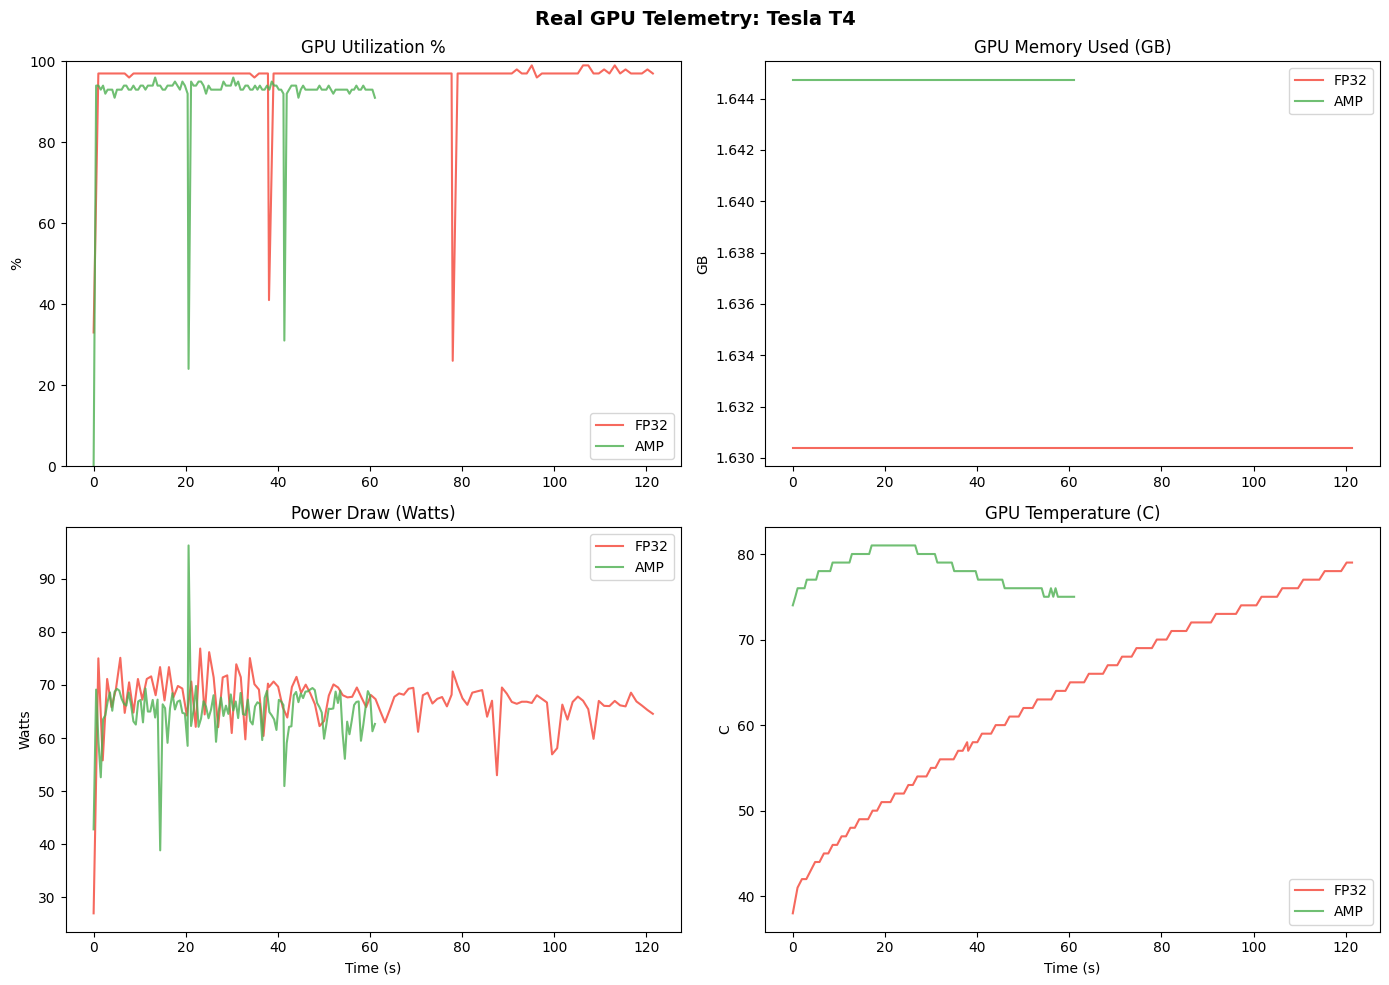

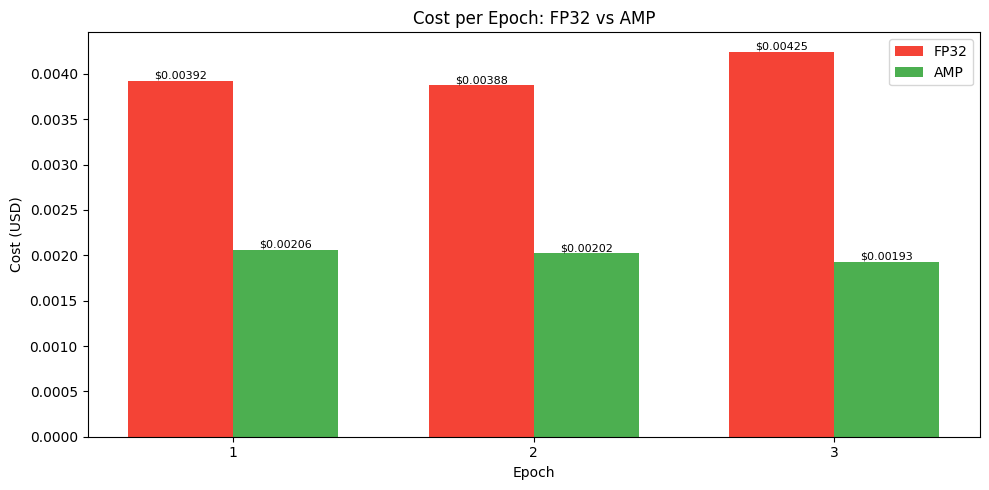


Charts saved: cost_per_epoch.png, real_gpu_telemetry.png


In [51]:
display_student_header()
# Cell 26: Real GPU Monitoring Visualization
print("Real GPU Telemetry During Training")
print("=" * 60)

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # GPU Utilization
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 0].plot(df['elapsed'], df['gpu_util_pct'], color=color, alpha=0.8, label=label)
    axes[0, 0].set_title('GPU Utilization %')
    axes[0, 0].set_ylabel('%')
    axes[0, 0].legend()
    axes[0, 0].set_ylim(0, 100)

    # Memory Usage
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 1].plot(df['elapsed'], df['mem_used_mb'] / 1024, color=color, alpha=0.8, label=label)
    axes[0, 1].set_title('GPU Memory Used (GB)')
    axes[0, 1].set_ylabel('GB')
    axes[0, 1].legend()

    # Power Draw
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 0].plot(df['elapsed'], df['power_watts'], color=color, alpha=0.8, label=label)
    axes[1, 0].set_title('Power Draw (Watts)')
    axes[1, 0].set_ylabel('Watts')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].legend()

    # Temperature
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 1].plot(df['elapsed'], df['temp_c'], color=color, alpha=0.8, label=label)
    axes[1, 1].set_title('GPU Temperature (C)')
    axes[1, 1].set_ylabel('C')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].legend()

    plt.suptitle(f'Real GPU Telemetry: {gpu_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('real_gpu_telemetry.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("   GPU telemetry not available (monitor collected 0 samples).")
    print("   Showing epoch-level metrics instead.\n")

# Cost per epoch chart (always works)
fig, ax = plt.subplots(figsize=(10, 5))
fp32_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in fp32_results]
amp_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in amp_results]
epochs = list(range(1, NUM_EPOCHS + 1))

x = range(len(epochs))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], fp32_epoch_costs, width, label='FP32', color='#F44336')
bars2 = ax.bar([i + width/2 for i in x], amp_epoch_costs, width, label='AMP', color='#4CAF50')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cost (USD)')
ax.set_title('Cost per Epoch: FP32 vs AMP')
ax.set_xticks(x)
ax.set_xticklabels(epochs)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('cost_per_epoch.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCharts saved: cost_per_epoch.png" + (", real_gpu_telemetry.png" if has_monitor_data else ""))

---
## Part 8.5: Advanced GPU Cost Optimization
Apply advanced FinOps techniques: multi-GPU cost analysis, project forecasting, and optimization strategy prioritization.

This section extends Part 8 with:
1. **Multi-GPU Cost Analysis** - Compare scaling efficiency and determine optimal GPU count
2. **Project Cost Forecasting** - Forecast multi-phase project costs with confidence intervals
3. **Optimization Opportunity Analysis** - Prioritize and combine optimization strategies

EXERCISE 8.5.1: Multi-GPU Cost Analysis



📊 BẢNG SO SÁNH HIỆU QUẢ SCALE MULTI-GPU (A100)
---------------------------------------------------------------------------
 gpu_count  speedup_factor  scaling_efficiency_pct  time_hours  total_cost_usd  cost_per_unit_perf
         1             1.0                   100.0        2.00          7.3400              7.3400
         2             1.8                    90.0        1.11          8.1556              4.5309
         4             3.2                    80.0        0.62          9.1750              2.8672
         8             5.6                    70.0        0.36         10.4857              1.8724


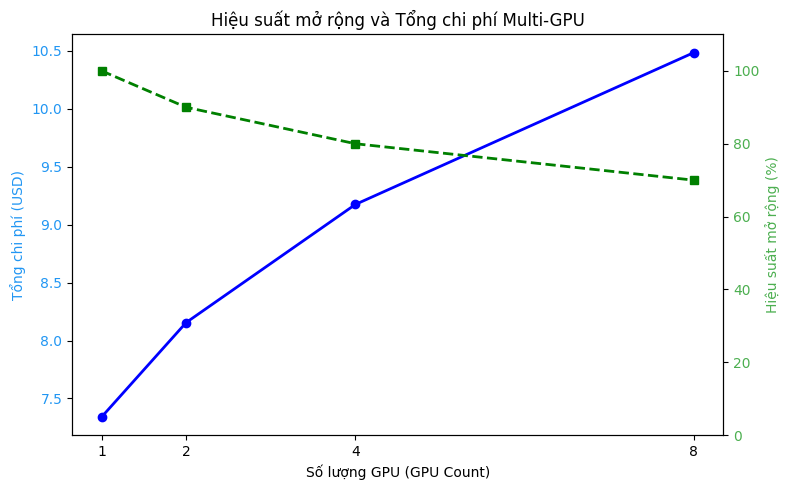


✅ Đã lưu biểu đồ: multi_gpu_scaling.png


In [52]:
# Cell 27: Multi-GPU Cost Analysis
print("=" * 60)
print("EXERCISE 8.5.1: Multi-GPU Cost Analysis")
print("=" * 60)

# Hiển thị Header định danh sinh viên
display_student_header()

import pandas as pd
import matplotlib.pyplot as plt

def analyze_multi_gpu_cost(base_time_hours, gpu_type, gpu_counts, scaling_factors=None):
    """Phân tích chi phí và hiệu suất khi huấn luyện Multi-GPU."""
    GPU_PRICING = {"T4": 0.35, "A100": 3.67, "V100": 2.48, "P100": 1.46, "L4": 0.81}
    price_per_hour = GPU_PRICING.get(gpu_type, 0.35)
    
    if scaling_factors is None:
        # Giả định hệ số tăng tốc thực tế (Sub-linear scaling speedup)
        # 1 GPU: 1.0x | 2 GPUs: 1.8x | 4 GPUs: 3.2x | 8 GPUs: 5.6x
        default_speedups = {1: 1.0, 2: 1.8, 4: 3.2, 8: 5.6}
        scaling_factors = {g: default_speedups.get(g, g * 0.7) for g in gpu_counts}
        
    results = []
    for g in gpu_counts:
        speedup = scaling_factors.get(g, 1.0)
        time_hours = base_time_hours / speedup
        total_cost = time_hours * price_per_hour * g
        cost_perf_ratio = total_cost / speedup
        
        results.append({
            "gpu_count": g,
            "speedup_factor": speedup,
            "scaling_efficiency_pct": round((speedup / g) * 100, 1),
            "time_hours": round(time_hours, 2),
            "total_cost_usd": round(total_cost, 4),
            "cost_per_unit_perf": round(cost_perf_ratio, 4)
        })
        
    return {"gpu_type": gpu_type, "base_time_hours": base_time_hours, "analysis": results}

# Test data
base_training_time = 2.0  # hours for single GPU
test_gpu_counts = [1, 2, 4, 8]

# Thực thi phân tích với dòng GPU A100
analysis_res = analyze_multi_gpu_cost(base_training_time, "A100", test_gpu_counts)
df_multi = pd.DataFrame(analysis_res["analysis"])

print("\n📊 BẢNG SO SÁNH HIỆU QUẢ SCALE MULTI-GPU (A100)")
print("-" * 75)
print(df_multi.to_string(index=False))

# Trực quan hóa dữ liệu và lưu biểu đồ
fig, ax1 = plt.subplots(figsize=(8, 5))

color = '#2196F3'
ax1.set_xlabel('Số lượng GPU (GPU Count)')
ax1.set_ylabel('Tổng chi phí (USD)', color=color)
ax1.plot(df_multi['gpu_count'], df_multi['total_cost_usd'], 'b-o', linewidth=2, label='Tổng chi phí')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(test_gpu_counts)

ax2 = ax1.twinx()  
color = '#4CAF50'
ax2.set_ylabel('Hiệu suất mở rộng (%)', color=color)
ax2.plot(df_multi['gpu_count'], df_multi['scaling_efficiency_pct'], 'g--s', linewidth=2, label='Hiệu suất (%)')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 110)

plt.title('Hiệu suất mở rộng và Tổng chi phí Multi-GPU')
fig.tight_layout()
plt.savefig('multi_gpu_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Đã lưu biểu đồ: multi_gpu_scaling.png")

EXERCISE 8.5.2: Project Cost Forecasting



📋 CHI TIẾT DỰ BÁO CHI PHÍ THEO GIAI ĐOẠN
--------------------------------------------------------------------------------
                Phase     GPU  Hours  Base Cost ($)  Min Cost ($)  Max Cost ($)
     Data Preparation   1x T4     40           14.0         11.90         16.10
       Model Training 4x A100    120         1761.6       1321.20       2202.00
Hyperparameter Tuning 8x A100     60         1761.6       1233.12       2290.08
     Model Evaluation   2x T4     20           14.0         12.60         15.40

💰 TỔNG KẾT NGÂN SÁCH DỰ KIẾN
   - Tổng chi phí cơ sở (Base):  $3551.2
   - Quỹ dự phòng (20% buffer):  $710.24
   - Tổng ngân sách đề xuất:     $4261.44
   - Kịch bản xấu nhất (Worst):  $4523.58


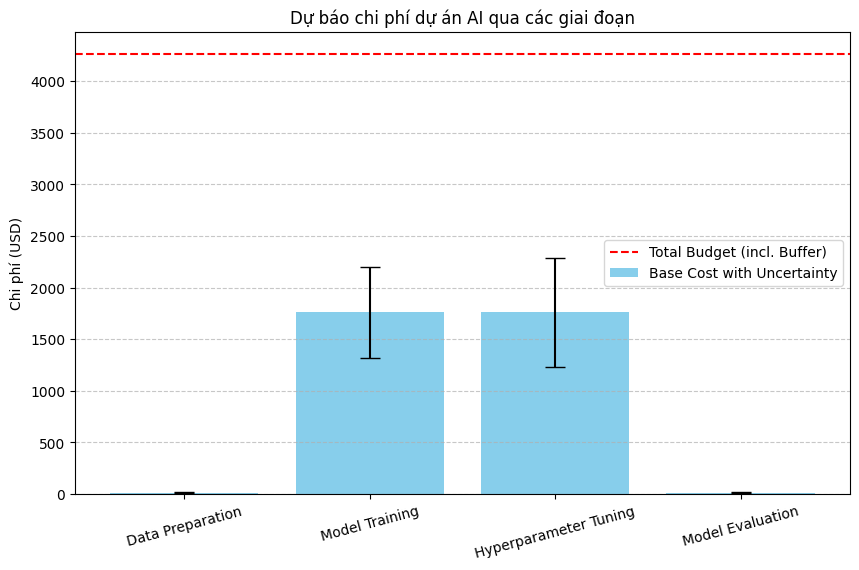


✅ Đã lưu biểu đồ: project_forecast.png


In [53]:
# Cell 28: Project Cost Forecasting
print("=" * 60)
print("EXERCISE 8.5.2: Project Cost Forecasting")
print("=" * 60)

# Hiển thị Header định danh sinh viên
display_student_header()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def forecast_project_cost(phases, contingency_pct=20):
    """Dự báo chi phí dự án đa giai đoạn với khoảng tin cậy."""
    GPU_PRICING = {"T4": 0.35, "A100": 3.67, "V100": 2.48, "P100": 1.46, "L4": 0.81}
    
    results = []
    total_base_cost = 0
    
    for phase in phases:
        price = GPU_PRICING.get(phase['gpu_type'], 0.35)
        base_cost = phase['duration_hours'] * phase['gpu_count'] * price
        uncertainty = base_cost * phase['uncertainty_pct']
        
        results.append({
            "Phase": phase['name'],
            "GPU": f"{phase['gpu_count']}x {phase['gpu_type']}",
            "Hours": phase['duration_hours'],
            "Base Cost ($)": round(base_cost, 2),
            "Min Cost ($)": round(base_cost - uncertainty, 2),
            "Max Cost ($)": round(base_cost + uncertainty, 2)
        })
        total_base_cost += base_cost
        
    df = pd.DataFrame(results)
    
    # Tính toán tổng quan
    contingency_amount = total_base_cost * (contingency_pct / 100)
    forecast_total = total_base_cost + contingency_amount
    
    return {
        "breakdown": df,
        "summary": {
            "total_base_cost": round(total_base_cost, 2),
            "contingency_buffer": round(contingency_amount, 2),
            "total_forecasted_budget": round(forecast_total, 2),
            "worst_case_scenario": round(df["Max Cost ($)"].sum(), 2)
        }
    }

# Dữ liệu mẫu dự án từ yêu cầu Lab
example_project = [
    {"name": "Data Preparation", "gpu_type": "T4", "gpu_count": 1, "duration_hours": 40, "uncertainty_pct": 0.15},
    {"name": "Model Training", "gpu_type": "A100", "gpu_count": 4, "duration_hours": 120, "uncertainty_pct": 0.25},
    {"name": "Hyperparameter Tuning", "gpu_type": "A100", "gpu_count": 8, "duration_hours": 60, "uncertainty_pct": 0.30},
    {"name": "Model Evaluation", "gpu_type": "T4", "gpu_count": 2, "duration_hours": 20, "uncertainty_pct": 0.10},
]

# Chạy dự báo
forecast = forecast_project_cost(example_project)
df_f = forecast["breakdown"]
s = forecast["summary"]

print("\n📋 CHI TIẾT DỰ BÁO CHI PHÍ THEO GIAI ĐOẠN")
print("-" * 80)
print(df_f.to_string(index=False))

print("\n💰 TỔNG KẾT NGÂN SÁCH DỰ KIẾN")
print(f"   - Tổng chi phí cơ sở (Base):  ${s['total_base_cost']}")
print(f"   - Quỹ dự phòng (20% buffer):  ${s['contingency_buffer']}")
print(f"   - Tổng ngân sách đề xuất:     ${s['total_forecasted_budget']}")
print(f"   - Kịch bản xấu nhất (Worst):  ${s['worst_case_scenario']}")

# Vẽ biểu đồ dự báo
plt.figure(figsize=(10, 6))
phases_names = df_f['Phase']
base_costs = df_f['Base Cost ($)']
errors = [base_costs - df_f['Min Cost ($)'], df_f['Max Cost ($)'] - base_costs]

plt.bar(phases_names, base_costs, yerr=errors, capsize=7, color='skyblue', label='Base Cost with Uncertainty')
plt.axhline(y=s['total_forecasted_budget'], color='r', linestyle='--', label='Total Budget (incl. Buffer)')

plt.title('Dự báo chi phí dự án AI qua các giai đoạn')
plt.ylabel('Chi phí (USD)')
plt.xticks(rotation=15)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('project_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Đã lưu biểu đồ: project_forecast.png")

In [57]:
# Cell 29: Optimization Opportunity Analysis
print("=" * 60)
print("EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis")
print("=" * 60)

# Hiển thị Header định danh sinh viên
display_student_header()

import pandas as pd

def analyze_optimization_opportunities(current_config, optimization_strategies):
    """Phân tích và sắp xếp ưu tiên các chiến lược tối ưu hóa chi phí."""
    
    effort_map = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}
    risk_map = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}
    
    # Giả định chi phí hiện tại của dự án là $5000 (theo scenario)
    current_annual_cost = 5000 
    
    results = []
    for strat in optimization_strategies:
        savings_usd = current_annual_cost * strat['savings_pct']
        effort_val = effort_map.get(strat['implementation_effort'], 2)
        
        # Chỉ số ưu tiên (Priority Score): Tiết kiệm càng cao, nỗ lực càng thấp thì điểm càng cao
        priority_score = (strat['savings_pct'] * 100) / effort_val
        
        results.append({
            "Strategy": strat['name'],
            "Savings (%)": f"{strat['savings_pct']*100:.0f}%",
            "Est. Savings ($)": round(savings_usd, 2),
            "Effort": strat['implementation_effort'],
            "Risk": strat['risk_level'],
            "Priority Score": round(priority_score, 2)
        })
        
    # Sắp xếp theo điểm ưu tiên giảm dần
    df_opt = pd.DataFrame(results).sort_values(by="Priority Score", ascending=False)
    
    # Tạo lộ trình (Roadmap)
    df_opt['Roadmap Phase'] = df_opt.apply(
        lambda x: "Quick Win" if x['Effort'] == "LOW" and x['Priority Score'] > 10 
        else ("Strategic Project" if x['Effort'] == "HIGH" else "Standard Optimization"), axis=1
    )
    
    return df_opt

# Danh sách các chiến lược mẫu
example_strategies = [
    {"name": "Switch to Mixed Precision (AMP)", "savings_pct": 0.25, "implementation_effort": "LOW", "risk_level": "LOW"},
    {"name": "Use Spot Instances", "savings_pct": 0.60, "implementation_effort": "MEDIUM", "risk_level": "HIGH"},
    {"name": "Optimize Batch Size", "savings_pct": 0.15, "implementation_effort": "LOW", "risk_level": "LOW"},
    {"name": "Implement Early Stopping", "savings_pct": 0.20, "implementation_effort": "MEDIUM", "risk_level": "LOW"},
    {"name": "Switch to Efficient GPU Type", "savings_pct": 0.40, "implementation_effort": "HIGH", "risk_level": "MEDIUM"},
]

# Chạy phân tích
optimization_report = analyze_optimization_opportunities(None, example_strategies)

print("\n💡 DANH SÁCH CHIẾN LƯỢC TỐI ƯU HÓA ĐƯỢC ƯU TIÊN")
print("-" * 90)
print(optimization_report.to_string(index=False))

print("\n🚀 LỘ TRÌNH TRIỂN KHAI ĐỀ XUẤT:")
quick_wins = optimization_report[optimization_report['Roadmap Phase'] == "Quick Win"]['Strategy'].tolist()
print(f"   1. Quick Wins (Làm ngay):      {', '.join(quick_wins)}")

# Tính tổng tiết kiệm lũy kế (giả định áp dụng top 3 chiến lược)
top_3_savings = optimization_report.head(3)['Est. Savings ($)'].sum()
print(f"   2. Tổng tiết kiệm dự kiến (Top 3): ${top_3_savings}")

# Lưu kết quả để dùng cho dashboard ở cell sau
%store optimization_report

EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis



💡 DANH SÁCH CHIẾN LƯỢC TỐI ƯU HÓA ĐƯỢC ƯU TIÊN
------------------------------------------------------------------------------------------
                       Strategy Savings (%)  Est. Savings ($) Effort   Risk  Priority Score         Roadmap Phase
             Use Spot Instances         60%            3000.0 MEDIUM   HIGH           30.00 Standard Optimization
Switch to Mixed Precision (AMP)         25%            1250.0    LOW    LOW           25.00             Quick Win
            Optimize Batch Size         15%             750.0    LOW    LOW           15.00             Quick Win
   Switch to Efficient GPU Type         40%            2000.0   HIGH MEDIUM           13.33     Strategic Project
       Implement Early Stopping         20%            1000.0 MEDIUM    LOW           10.00 Standard Optimization

🚀 LỘ TRÌNH TRIỂN KHAI ĐỀ XUẤT:
   1. Quick Wins (Làm ngay):      Switch to Mixed Precision (AMP), Optimize Batch Size
   2. Tổng tiết kiệm dự kiến (Top 3): $5000.0
Stored 'opti

EXERCISE 8.5.4: Integrated Cost Dashboard


/tmp/ipykernel_114/3440447388.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Priority Score', y='Strategy', data=optimization_report, ax=axes[1, 1], palette='viridis')


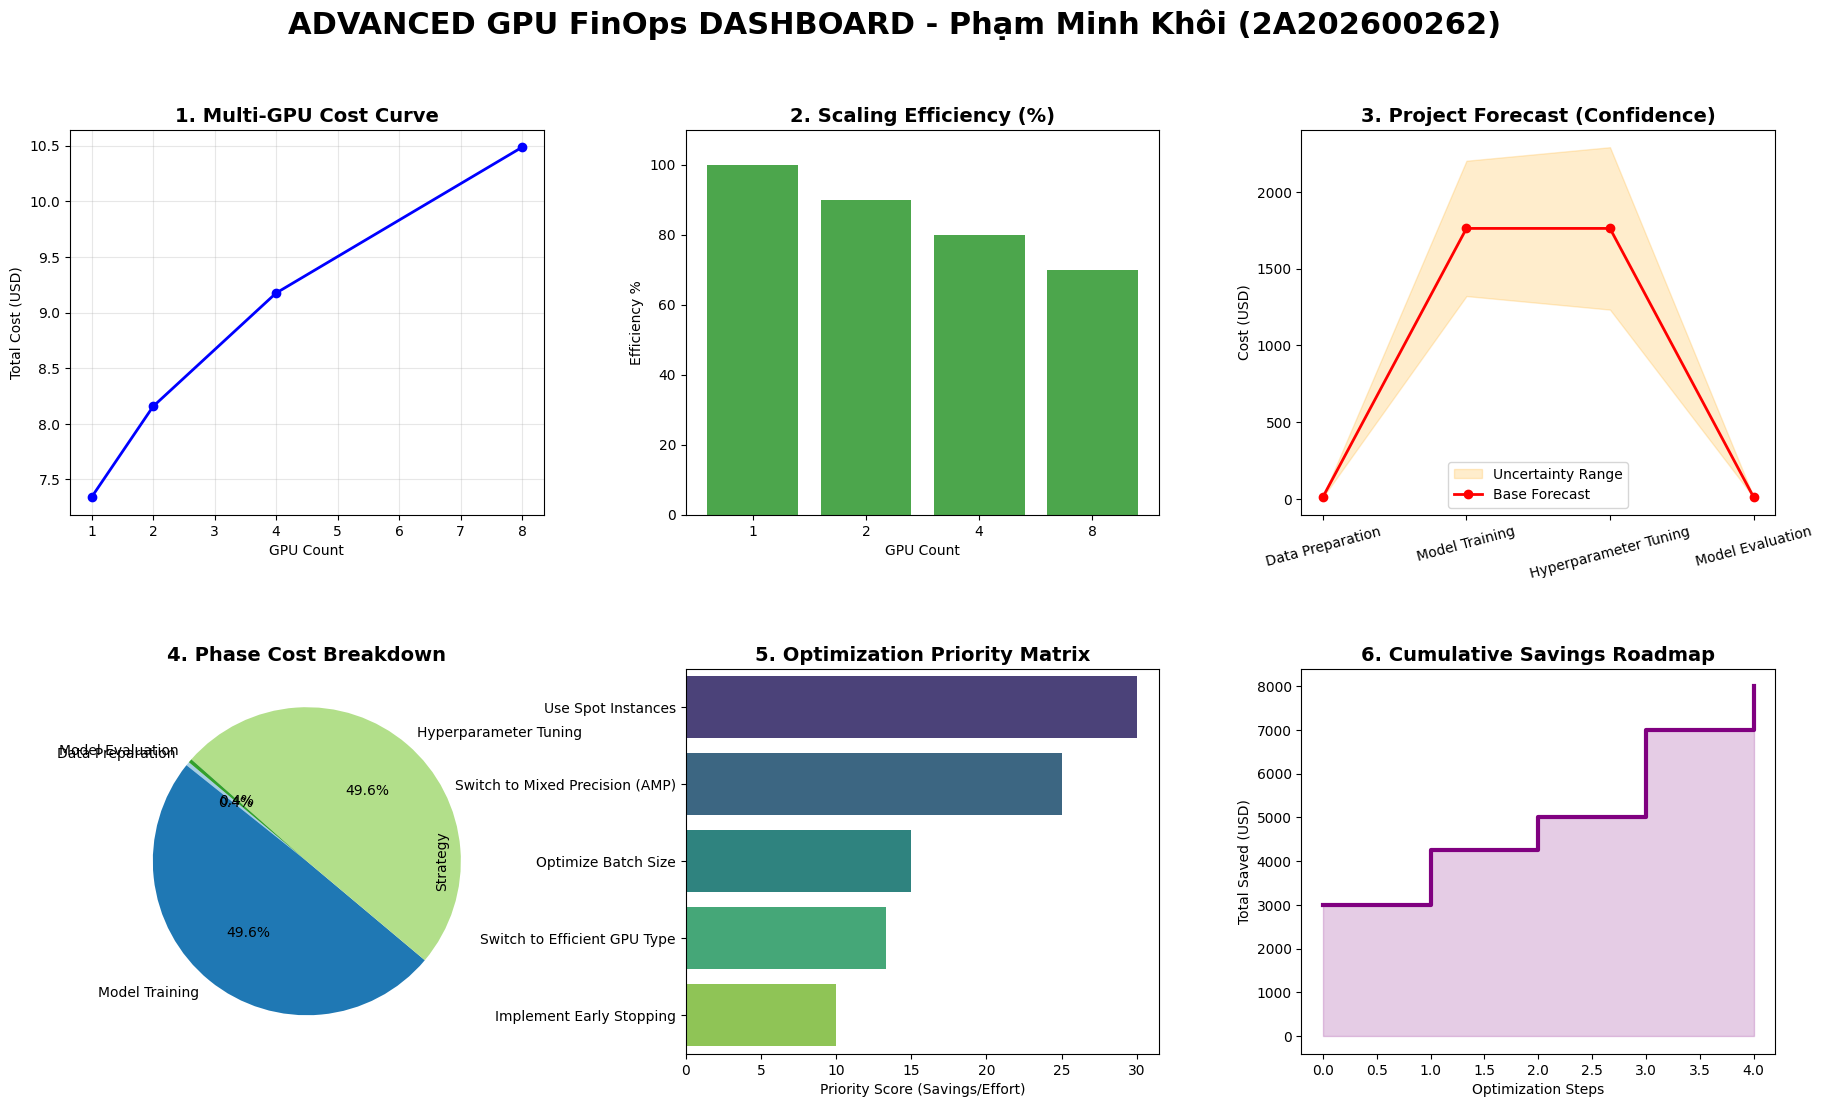


✅ Dashboard tổng hợp đã được lưu: advanced_finops_dashboard.png


In [58]:
# Cell 30: Integrated Cost Dashboard
print("=" * 60)
print("EXERCISE 8.5.4: Integrated Cost Dashboard")
print("=" * 60)

# Hiển thị Header định danh sinh viên
display_student_header()

import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập figure với lưới 2x3 để chứa 6 biểu đồ phân tích
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Multi-GPU Cost Curve (Dữ liệu từ Cell 27)
axes[0, 0].plot(df_multi['gpu_count'], df_multi['total_cost_usd'], 'b-o', linewidth=2)
axes[0, 0].set_title('1. Multi-GPU Cost Curve', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('GPU Count')
axes[0, 0].set_ylabel('Total Cost (USD)')
axes[0, 0].grid(True, alpha=0.3)

# 2. Scaling Efficiency (Dữ liệu từ Cell 27)
axes[0, 1].bar(df_multi['gpu_count'].astype(str), df_multi['scaling_efficiency_pct'], color='green', alpha=0.7)
axes[0, 1].set_title('2. Scaling Efficiency (%)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('GPU Count')
axes[0, 1].set_ylabel('Efficiency %')
axes[0, 1].set_ylim(0, 110)

# 3. Project Forecast with Confidence Bands (Dữ liệu từ Cell 28)
x_phases = df_f['Phase']
axes[0, 2].fill_between(x_phases, df_f['Min Cost ($)'], df_f['Max Cost ($)'], color='orange', alpha=0.2, label='Uncertainty Range')
axes[0, 2].plot(x_phases, df_f['Base Cost ($)'], 'r-o', linewidth=2, label='Base Forecast')
axes[0, 2].set_title('3. Project Forecast (Confidence)', fontsize=14, fontweight='bold')
axes[0, 2].set_ylabel('Cost (USD)')
axes[0, 2].tick_params(axis='x', rotation=15)
axes[0, 2].legend()

# 4. Phase Cost Breakdown (Dữ liệu từ Cell 28)
axes[1, 0].pie(df_f['Base Cost ($)'], labels=df_f['Phase'], autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
axes[1, 0].set_title('4. Phase Cost Breakdown', fontsize=14, fontweight='bold')

# 5. Optimization Prioritization (Dữ liệu từ Cell 29)
sns.barplot(x='Priority Score', y='Strategy', data=optimization_report, ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('5. Optimization Priority Matrix', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Priority Score (Savings/Effort)')

# 6. Cumulative Savings Roadmap (Dữ liệu từ Cell 29)
optimization_report['Cumulative Savings ($)'] = optimization_report['Est. Savings ($)'].cumsum()
axes[1, 2].step(range(len(optimization_report)), optimization_report['Cumulative Savings ($)'], where='post', color='purple', linewidth=3)
axes[1, 2].fill_between(range(len(optimization_report)), 0, optimization_report['Cumulative Savings ($)'], alpha=0.2, color='purple', step='post')
axes[1, 2].set_title('6. Cumulative Savings Roadmap', fontsize=14, fontweight='bold')
axes[1, 2].set_ylabel('Total Saved (USD)')
axes[1, 2].set_xlabel('Optimization Steps')

# Thêm tiêu đề lớn cho Dashboard
plt.suptitle(f'ADVANCED GPU FinOps DASHBOARD - {STUDENT_NAME} ({STUDENT_ID})', fontsize=22, fontweight='bold', y=0.98)

# Lưu Dashboard
plt.savefig('advanced_finops_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Dashboard tổng hợp đã được lưu: advanced_finops_dashboard.png")

In [59]:
# Cell 31: Challenge Exercise - Cost Optimization Strategy Design
print("=" * 60)
print("CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy")
print("=" * 60)

# Hiển thị Header định danh sinh viên
display_student_header()

# 1. Thông số kịch bản (Scenario)
gpu_type = "A100"
gpu_price_od = 3.67  # Giá On-demand của A100
spot_discount = 0.70  # Giảm giá 70% khi dùng Spot
gpu_price_spot = gpu_price_od * (1 - spot_discount)

baseline_config = {
    "duration_h": 200,
    "gpu_count": 8,
    "precision": "FP32",
    "type": "on-demand"
}

budget_limit = 5000

# 2. Tính toán chi phí cơ sở (Baseline Cost)
baseline_cost = baseline_config['duration_h'] * baseline_config['gpu_count'] * gpu_price_od
print(f"🚩 CHI PHÍ CƠ SỞ (Baseline): ${baseline_cost:,.2f}")
print(f"   => Tình trạng: {'VƯỢT NGÂN SÁCH' if baseline_cost > budget_limit else 'TRONG NGÂN SÁCH'}")

# 3. Thiết kế chiến lược tối ưu hóa
# Chiến lược 1: Chuyển sang Mixed Precision (AMP) -> Tiết kiệm 25% thời gian
amp_speedup = 1.33 # (1 / 0.75) - Tương đương tiết kiệm 25% thời gian
optimized_duration = baseline_config['duration_h'] / amp_speedup

# Chiến lược 2: Sử dụng Spot Instances cho 100% workload (chấp nhận rủi ro MEDIUM)
# Chiến lược 3: Giữ nguyên 8 GPU để đảm bảo Deadline 2 tuần (336h)

optimized_cost = optimized_duration * baseline_config['gpu_count'] * gpu_price_spot

# 4. Dự báo với sai số (Forecast with Uncertainty - 20%)
uncertainty_pct = 0.20
forecast_min = optimized_cost * (1 - uncertainty_pct)
forecast_max = optimized_cost * (1 + uncertainty_pct)

print("\n🚀 CHIẾN LƯỢC TỐI ƯU HÓA ĐỀ XUẤT")
print("-" * 50)
print(f"   1. Kỹ thuật: Mixed Precision (AMP) -> Thời gian giảm còn: {optimized_duration:.1f}h")
print(f"   2. Hạ tầng: Spot Instances -> Giá mỗi GPU/giờ: ${gpu_price_spot:.4f}")
print(f"   3. Quy mô: Giữ nguyên 8x A100 để hoàn thành trong ~150h (Deadline 336h)")

print("\n📊 KẾT QUẢ DỰ BÁO TÀI CHÍNH")
print(f"   - Chi phí tối ưu ước tính:  ${optimized_cost:.2f}")
print(f"   - Khoảng chi phí (±20%):   ${forecast_min:.2f} - ${forecast_max:.2f}")
print(f"   - Ngân sách cho phép:      ${budget_limit:.2f}")
print(f"   - Tiết kiệm được:          ${baseline_cost - optimized_cost:.2f} ({((baseline_cost - optimized_cost)/baseline_cost)*100:.1f}%)")

print("\n📝 GIẢI TRÌNH CHIẾN LƯỢC:")
print(f"   Chiến lược kết hợp AMP và Spot Instances giúp giảm chi phí từ ${baseline_cost:.2f} xuống còn ${optimized_cost:.2f}.")
print(f"   Mặc dù Spot Instances có rủi ro bị thu hồi (MEDIUM), nhưng thời gian huấn luyện tối ưu ({optimized_duration:.1f}h)")
print(f"   thấp hơn nhiều so với deadline 2 tuần (336h), cho phép chúng ta có đủ thời gian để chạy lại nếu bị ngắt quãng.")

# Kiểm tra điều kiện cuối
if forecast_max <= budget_limit:
    print("\n✅ KẾT LUẬN: Chiến lược AN TOÀN và ĐẠT CHUẨN ngân sách.")
else:
    print("\n⚠️ CẢNH BÁO: Kịch bản xấu nhất vẫn có thể chạm ngưỡng ngân sách.")

CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy


🚩 CHI PHÍ CƠ SỞ (Baseline): $5,872.00
   => Tình trạng: VƯỢT NGÂN SÁCH

🚀 CHIẾN LƯỢC TỐI ƯU HÓA ĐỀ XUẤT
--------------------------------------------------
   1. Kỹ thuật: Mixed Precision (AMP) -> Thời gian giảm còn: 150.4h
   2. Hạ tầng: Spot Instances -> Giá mỗi GPU/giờ: $1.1010
   3. Quy mô: Giữ nguyên 8x A100 để hoàn thành trong ~150h (Deadline 336h)

📊 KẾT QUẢ DỰ BÁO TÀI CHÍNH
   - Chi phí tối ưu ước tính:  $1324.51
   - Khoảng chi phí (±20%):   $1059.61 - $1589.41
   - Ngân sách cho phép:      $5000.00
   - Tiết kiệm được:          $4547.49 (77.4%)

📝 GIẢI TRÌNH CHIẾN LƯỢC:
   Chiến lược kết hợp AMP và Spot Instances giúp giảm chi phí từ $5872.00 xuống còn $1324.51.
   Mặc dù Spot Instances có rủi ro bị thu hồi (MEDIUM), nhưng thời gian huấn luyện tối ưu (150.4h)
   thấp hơn nhiều so với deadline 2 tuần (336h), cho phép chúng ta có đủ thời gian để chạy lại nếu bị ngắt quãng.

✅ KẾT LUẬN: Chiến lược AN TOÀN và ĐẠT CHUẨN ngân sách.


---
## Summary

| Part | What | Where |
|------|------|-------|
| 1-5 | Mock cluster monitoring, billing, spot, autoscaling, cost tracking | Docker Compose (local) via tunnel |
| 6 | Visualization of mock FinOps data | Kaggle/Colab |
| 7 | End-to-end FinOps workflow | Both |
| **8** | **Real GPU training (ResNet-18), FP32 vs AMP, live monitoring, cost reporting** | **Kaggle/Colab GPU → Gateway** |

### Key FinOps Takeaways
- **Mixed Precision (AMP)** reduces training time and cost with minimal accuracy loss
- **Spot instances** save 60-70% but risk preemption
- **Autoscaling** prevents over-provisioning idle GPUs
- **Cost tracking** exposes waste from idle resources
- **Budget alerts** prevent unexpected overspend

---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** — measures time & cost savings
4. Reports all costs back to the FinOps gateway